In this file,

we visualize full and intra-layer HVG adjacency sparsity patterns, and summarize electrode-wise intra-layer edge counts.

In [13]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp
from scipy.sparse import load_npz

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
GRAPH_DIR = Path("/content/drive/MyDrive/project_data")
GRAPH_DIR.mkdir(parents=True, exist_ok=True)

In [16]:
graph_ids = [
    "ictal_1735_1740",
    "ictal_1740_1745",
    "ictal_1745_1750",
    "interictal_3110_3115",
    "interictal_3115_3120",
    "interictal_3120_3125",
]

In [17]:
def load_graph_files(graph_id, graph_dir=GRAPH_DIR):
    edge_path = graph_dir / "edges" / f"{graph_id}_edges.csv"
    node_path = graph_dir / "nodes" / f"{graph_id}_nodes.csv"
    adj_path = graph_dir / "adjacency_sparse" / f"{graph_id}_adjacency_sparse.npz"
    meta_path = graph_dir / "metadata" / f"{graph_id}_metadata.json"

    edges = pd.read_csv(edge_path)
    nodes = pd.read_csv(node_path)
    adj = load_npz(adj_path)

    with open(meta_path, "r", encoding="utf-8") as f:
        meta = json.load(f)

    return edges, nodes, adj, meta

In [18]:
def get_intra_edges(edges):
    intra = edges[edges["edge_type"] == "intra"].copy()
    intra["source_electrode"] = intra["Source"].str.split("_t").str[0]
    intra["target_electrode"] = intra["Target"].str.split("_t").str[0]
    return intra

In [41]:
# full adjacency visualization
def plot_full_adjacency_sparsity_pattern(
    graph_id,
    graph_dir=GRAPH_DIR,
    markersize=0.15,
    figsize=(8, 8)
):
    edges, nodes, adj, meta = load_graph_files(graph_id, graph_dir)

    plt.figure(figsize=figsize)
    plt.spy(adj, markersize=markersize)
    plt.title(f"Full Multiplex Adjacency Sparsity Pattern: {graph_id}")
    plt.xlabel("Node index")
    plt.ylabel("Node index")
    plt.tight_layout()
    plt.show()

    print(f"[{graph_id}]")
    print(f"n_nodes       : {meta['n_nodes']}")
    print(f"n_edges       : {meta['n_edges']}")
    print(f"n_intra_edges : {meta['n_intra_edges']}")
    print(f"n_inter_edges : {meta['n_inter_edges']}")


In [42]:
# intra only adjacency
def build_intra_only_adjacency(nodes, adj):
    """
    Keep only intra-layer blocks from the full multiplex adjacency.

    Parameters
    ----------
    nodes : pd.DataFrame
        Node table.
    adj : scipy sparse matrix
        Full multiplex adjacency matrix.

    Returns
    -------
    scipy.sparse.csr_matrix
        Sparse matrix containing only intra-layer blocks.
    """
    electrodes = nodes["electrode"].unique().tolist()
    intra_adj = sp.lil_matrix(adj.shape, dtype=np.int8)

    for elec in electrodes:
        idx = nodes.index[nodes["electrode"] == elec].to_numpy()
        block = adj[idx[:, None], idx]
        intra_adj[idx[:, None], idx] = block

    return intra_adj.tocsr()

In [46]:
# group average matrix helper
def build_group_average_matrix(feature_df):
    group_labels = [
        "ictal" if idx.startswith("ictal") else "interictal"
        for idx in feature_df.index
    ]
    grouped = feature_df.copy()
    grouped["group"] = group_labels
    avg_df = grouped.groupby("group").mean()
    return avg_df

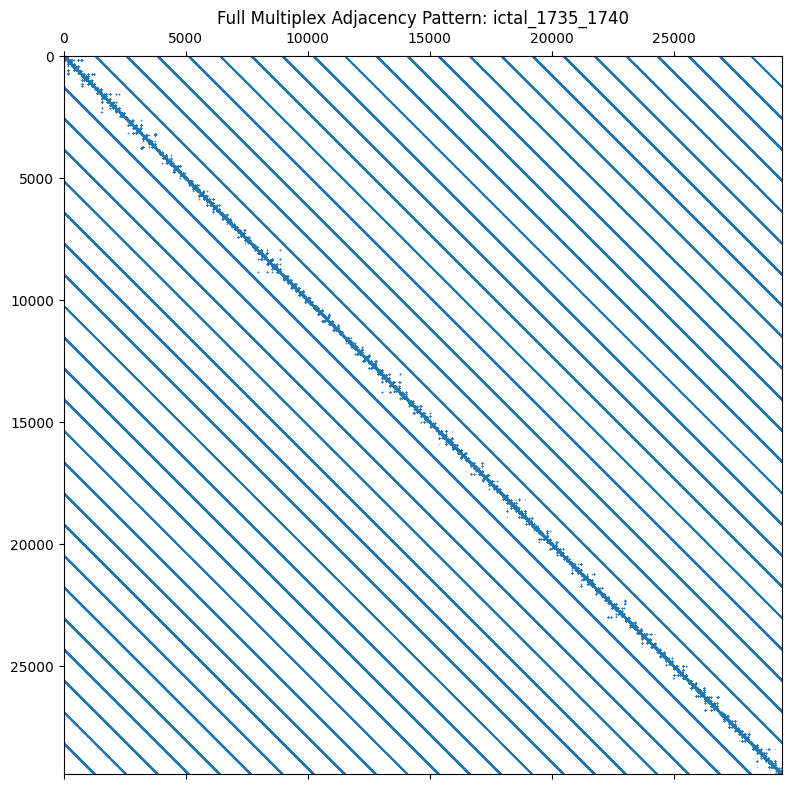

[ictal_1735_1740]
n_nodes       : 29440
n_edges       : 380805
n_intra_edges : 56965
n_inter_edges : 323840


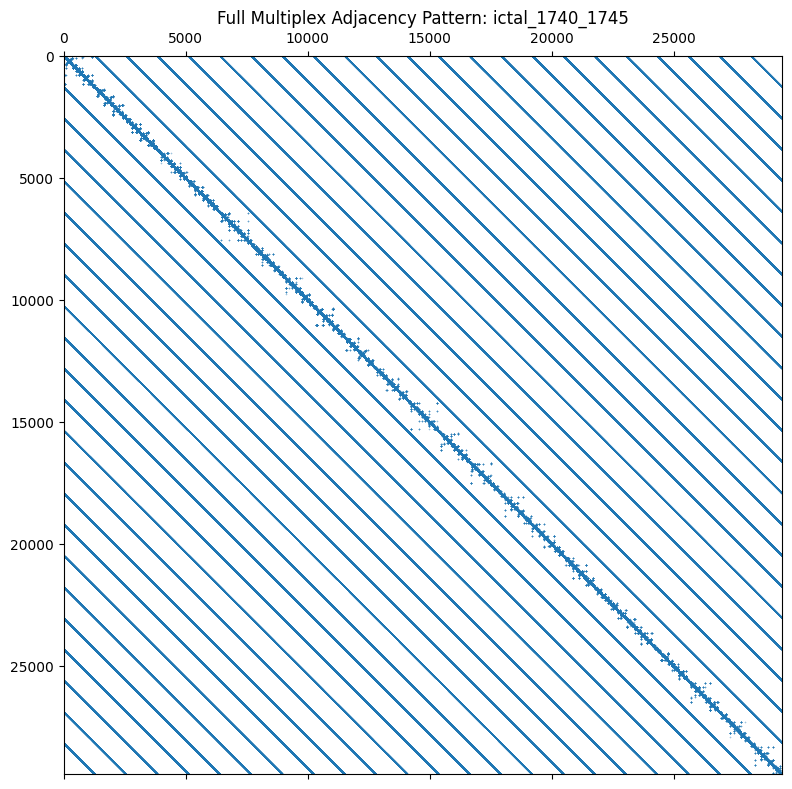

[ictal_1740_1745]
n_nodes       : 29440
n_edges       : 381233
n_intra_edges : 57393
n_inter_edges : 323840


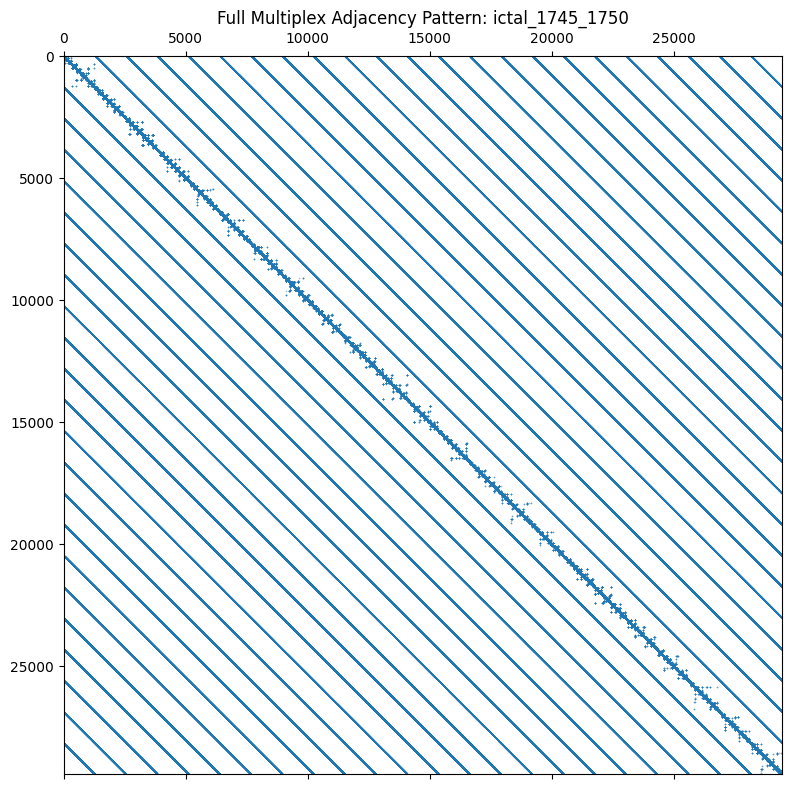

[ictal_1745_1750]
n_nodes       : 29440
n_edges       : 381155
n_intra_edges : 57315
n_inter_edges : 323840


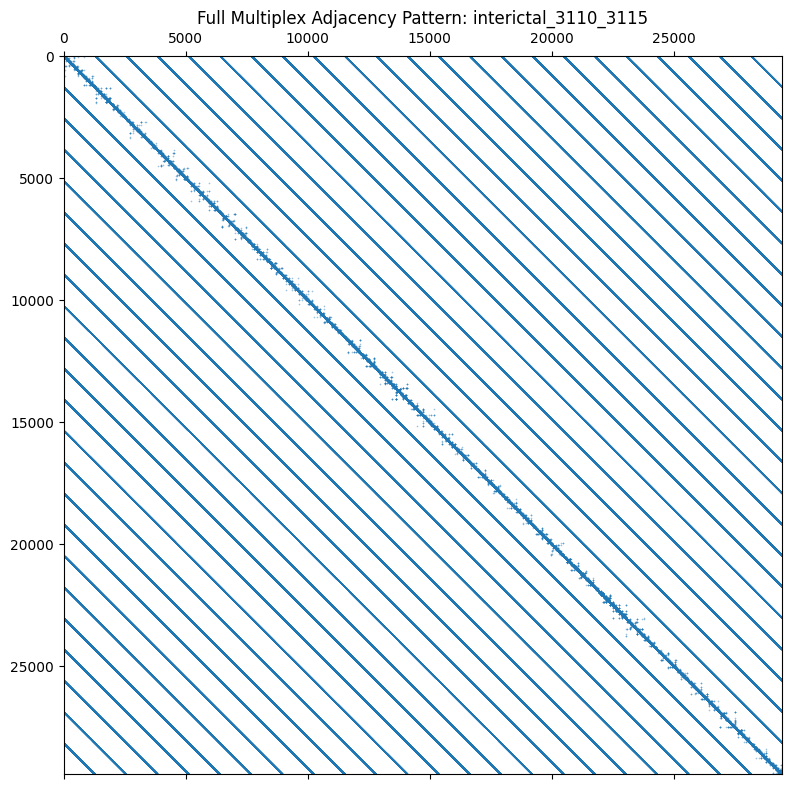

[interictal_3110_3115]
n_nodes       : 29440
n_edges       : 382132
n_intra_edges : 58292
n_inter_edges : 323840


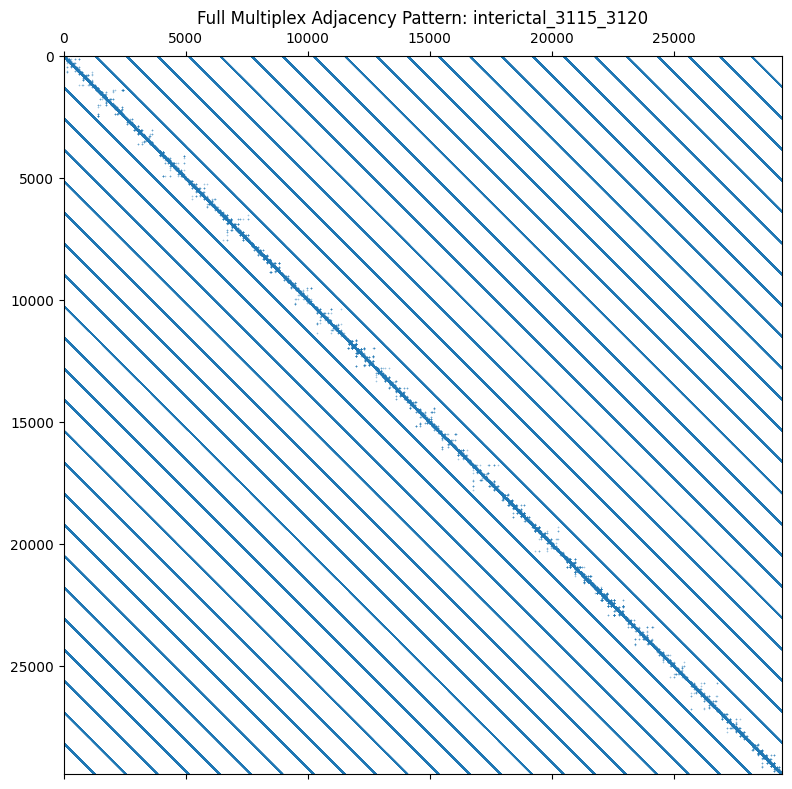

[interictal_3115_3120]
n_nodes       : 29440
n_edges       : 382133
n_intra_edges : 58293
n_inter_edges : 323840


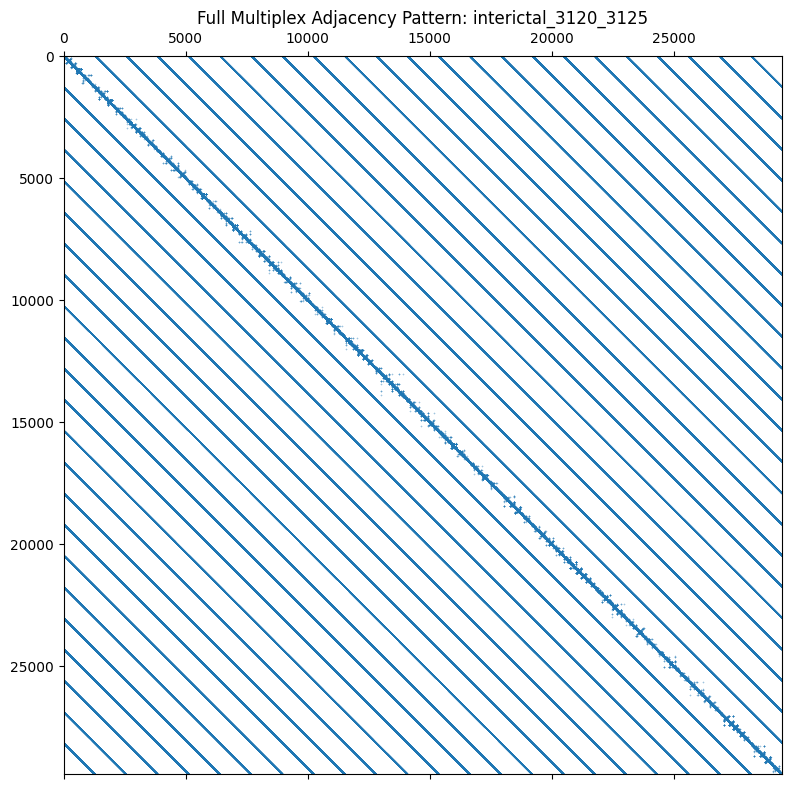

[interictal_3120_3125]
n_nodes       : 29440
n_edges       : 381864
n_intra_edges : 58024
n_inter_edges : 323840


In [61]:
# run it
for gid in graph_ids:
    plot_full_adjacency_pattern(
        graph_id=gid,
        graph_dir=GRAPH_DIR,
        markersize=0.12,
    )

In [60]:
# electrode-wise itra-layer edge count table
feature_rows = []

for gid in graph_ids:
    counts = get_intra_edge_counts_per_electrode(
        graph_id=gid,
        graph_dir=GRAPH_DIR
    )
    counts.name = gid
    feature_rows.append(counts)

feature_df = pd.DataFrame(feature_rows)
display(feature_df)

source_electrode,C3-P3,C4-P4,CZ-PZ,F3-C3,F4-C4,F7-T7,F8-T8,FP1-F3,FP1-F7,FP2-F4,...,FZ-CZ,P3-O1,P4-O2,P7-O1,P7-T7,P8-O2,T7-FT9,T7-P7,T8-P8-0,T8-P8-1
ictal_1735_1740,2473,2502,2469,2460,2481,2458,2465,2499,2501,2437,...,2480,2472,2507,2452,2479,2507,2444,2489,2490,2490
ictal_1740_1745,2480,2514,2475,2505,2501,2478,2502,2483,2499,2518,...,2511,2477,2498,2464,2505,2529,2460,2462,2518,2518
ictal_1745_1750,2454,2524,2486,2479,2512,2440,2518,2488,2478,2493,...,2502,2492,2506,2460,2495,2518,2498,2457,2528,2528
interictal_3110_3115,2534,2533,2521,2533,2535,2534,2530,2544,2543,2540,...,2513,2539,2539,2544,2537,2547,2536,2531,2531,2531
interictal_3115_3120,2527,2549,2532,2525,2528,2530,2534,2536,2535,2538,...,2524,2531,2544,2534,2531,2547,2539,2527,2543,2543
interictal_3120_3125,2530,2537,2531,2529,2507,2523,2516,2513,2502,2502,...,2512,2534,2542,2526,2532,2537,2528,2531,2521,2521


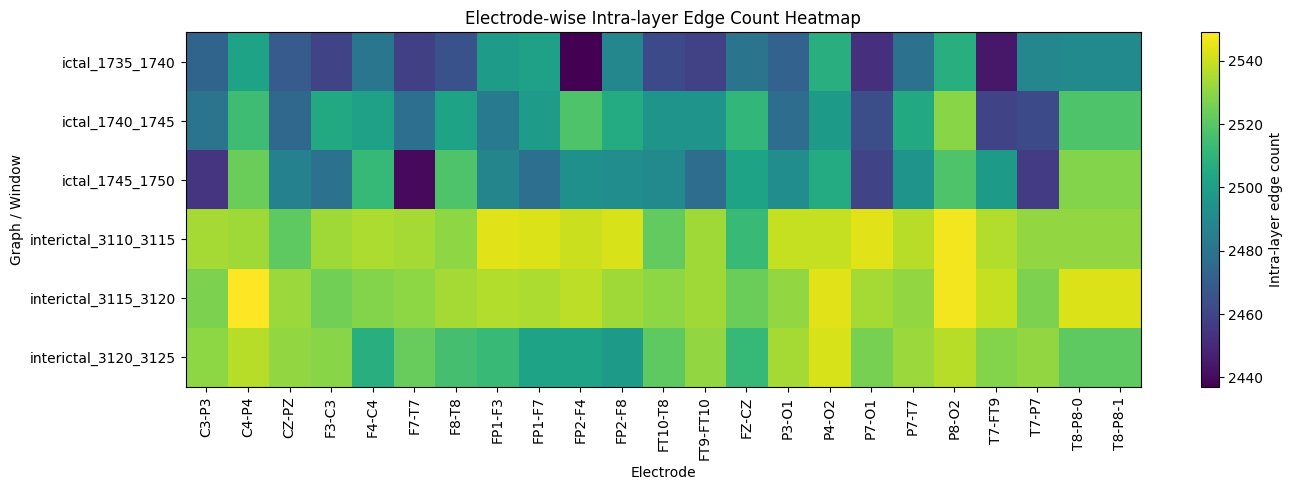

In [53]:
# Electrode-wise edge count heatmap
def plot_electrode_edgecount_heatmap(feature_df, figsize=(14, 5)):
    plt.figure(figsize=figsize)
    plt.imshow(feature_df.values, aspect="auto", cmap="viridis")
    plt.colorbar(label="Intra-layer edge count")
    plt.xticks(
        ticks=np.arange(len(feature_df.columns)),
        labels=feature_df.columns,
        rotation=90
    )
    plt.yticks(
        ticks=np.arange(len(feature_df.index)),
        labels=feature_df.index
    )
    plt.title("Electrode-wise Intra-layer Edge Count Heatmap")
    plt.xlabel("Electrode")
    plt.ylabel("Graph / Window")
    plt.tight_layout()
    plt.show()

plot_electrode_edgecount_heatmap(feature_df, figsize=(14, 5))

In [54]:
avg_df = build_group_average_matrix(feature_df)
display(avg_df)

source_electrode,C3-P3,C4-P4,CZ-PZ,F3-C3,F4-C4,F7-T7,F8-T8,FP1-F3,FP1-F7,FP2-F4,...,FZ-CZ,P3-O1,P4-O2,P7-O1,P7-T7,P8-O2,T7-FT9,T7-P7,T8-P8-0,T8-P8-1
group,,,,,,,,,,,,,,,,,,,,,
ictal,2469.000000,2513.333333,2476.666667,2481.333333,2498.000000,2458.666667,2495.000000,2490.0,2492.666667,2482.666667,...,2497.666667,2480.333333,2503.666667,2458.666667,2493.000000,2518.000000,2467.333333,2469.333333,2512.000000,2512.000000
interictal,2530.333333,2539.666667,2528.000000,2529.000000,2523.333333,2529.000000,2526.666667,2531.0,2526.666667,2526.666667,...,2516.333333,2534.666667,2541.666667,2534.666667,2533.333333,2543.666667,2534.333333,2529.666667,2531.666667,2531.666667


In [55]:
def plot_group_average_heatmap(avg_df, figsize=(14, 3)):
    plt.figure(figsize=figsize)
    plt.imshow(avg_df.values, aspect="auto", cmap="viridis")
    plt.colorbar(label="Average intra-layer edge count")
    plt.xticks(
        ticks=np.arange(len(avg_df.columns)),
        labels=avg_df.columns,
        rotation=90
    )
    plt.yticks(
        ticks=np.arange(len(avg_df.index)),
        labels=avg_df.index
    )
    plt.title("Group-average Electrode-wise Intra-layer Edge Count Heatmap")
    plt.xlabel("Electrode")
    plt.ylabel("Group")
    plt.tight_layout()
    plt.show()

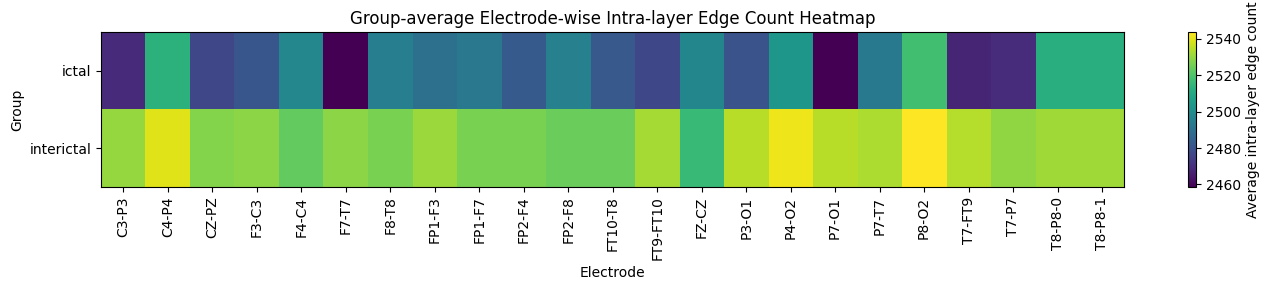

In [56]:
plot_group_average_heatmap(avg_df, figsize=(14, 3))

In [57]:
def plot_group_difference_heatmap(avg_df, figsize=(14, 2.5)):
    diff = (avg_df.loc["ictal"] - avg_df.loc["interictal"]).to_frame().T

    plt.figure(figsize=figsize)
    plt.imshow(diff.values, aspect="auto", cmap="bwr")
    plt.colorbar(label="Ictal - Interictal edge count")
    plt.xticks(
        ticks=np.arange(len(diff.columns)),
        labels=diff.columns,
        rotation=90
    )
    plt.yticks([0], ["ictal - interictal"])
    plt.title("Group Difference Heatmap (Ictal - Interictal)")
    plt.xlabel("Electrode")
    plt.tight_layout()
    plt.show()

    return diff

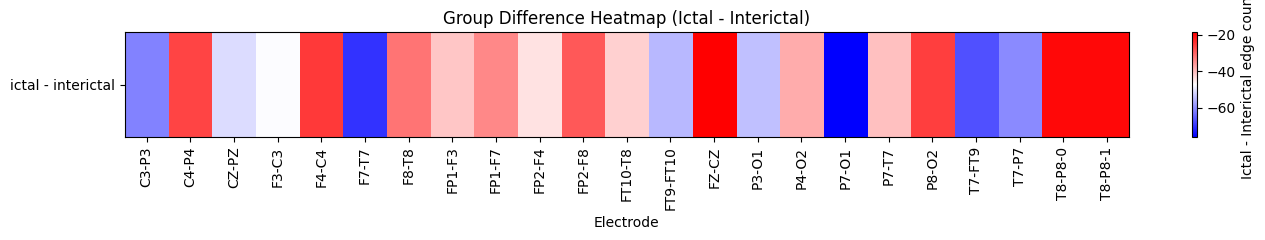

source_electrode,C3-P3,C4-P4,CZ-PZ,F3-C3,F4-C4,F7-T7,F8-T8,FP1-F3,FP1-F7,FP2-F4,...,FZ-CZ,P3-O1,P4-O2,P7-O1,P7-T7,P8-O2,T7-FT9,T7-P7,T8-P8-0,T8-P8-1
0,-61.333333,-26.333333,-51.333333,-47.666667,-25.333333,-70.333333,-31.666667,-41.0,-34.0,-44.0,...,-18.666667,-54.333333,-38.0,-76.0,-40.333333,-25.666667,-67.0,-60.333333,-19.666667,-19.666667


In [58]:
diff_df = plot_group_difference_heatmap(avg_df, figsize=(14, 2.5))
display(diff_df)